
# Notebook 06 — Signaux faibles : commentaires de vente et réseau de commercialisation

**Copilote Financier — Groupe Angelotti | Mémoire M2 MIASHS**

Axe transverse du copilote : exploiter ce que les champs structurés ne
captent pas. Deux matières premières :

- les **commentaires libres** des dossiers de vente (~9 700 textes) et les
  **motifs de désistement** — module *données séquentielles* (texte), cours
  *Similarity-Based Text Retrieval* (B. Priya C, 2025) ;
- le **réseau vendeurs ↔ opérations** — module *analyse de réseaux
  sociaux*. Ce module n'a pas de support PDF dans le dossier `Cours/` :
  nous employons donc le formalisme standard du domaine (centralité de
  degré, intermédiarité, communautés par modularité) en citant M. E. J.
  Newman, *Networks*, 2ᵉ éd., Oxford University Press, 2018.

Concepts mobilisés : **TF-IDF** (slide 7 du cours de text retrieval),
**similarité cosinus** (slide 12), pipeline de recherche (slides 20-21),
**Naive Bayes** (absent des cours — introduit d'après Azencott,
*Introduction au Machine Learning*, référence bibliographique des cours de
classification), **entropie** (cours d'arbres de décision, slide 16),
**divergence de Kullback-Leibler** (absente des cours — source externe),
centralités et **modularité** (Newman).


In [1]:
# --- Amorçage : exécution locale ou Google Colab ---
import pathlib, subprocess, sys

racine = pathlib.Path.cwd()
while not (racine / "src" / "nettoyage.py").exists() and racine != racine.parent:
    racine = racine.parent
if not (racine / "src" / "nettoyage.py").exists():  # environnement Colab vierge
    subprocess.run(["git", "clone", "-b", "claude/copilote-financier-angelotti-72c614",
                    "https://github.com/yzasmin/MemoireM2S2.git"], check=True)
    racine = pathlib.Path.cwd() / "MemoireM2S2"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                    str(racine / "requirements.txt")], check=True)

sys.path.insert(0, str(racine / "src"))
import base_sql

if not base_sql.DB.exists():  # reconstruit data/copilote.db depuis donnéebrut/
    base_sql.construire_base()
DB = base_sql.DB
print("Base prête :", DB)


Base prête : /home/user/MemoireM2S2/data/copilote.db



## 1. Problème métier *(docs/03_besoins_metier.md, axe transverse)*

Les exports de gestion contiennent des champs structurés (prix, dates,
statuts) mais les événements qui **précèdent** un désistement — refus de
prêt en cours, remise consentie « hors pack », plis SRU non retirés,
contentieux — ne vivent souvent que dans le **commentaire libre** du
dossier. Deux besoins formalisés :

- **B-T1** : exploiter les 9 688 commentaires libres de vente (mentions de
  refus de prêt, de remises cachées « prix hors pack », de contentieux)
  comme **signal précoce de désistement** ;
- **B-T2** : cartographier le **réseau vendeurs ↔ opérations** pour
  identifier les vendeurs pivots et les dépendances commerciales.

Le plan du notebook suit ces deux besoins : corpus et prétraitement (§2),
représentation TF-IDF (§3), moteur de recherche de dossiers semblables
(§4), classification du risque de désistement à partir du texte (§5),
profils de motifs par agence via entropie et divergence KL (§6), réseau de
commercialisation (§7), synthèse (§8).



## 2. Corpus et prétraitement *(cours text retrieval, slide 19)*

Le cours recommande comme prétraitement : *« remove stopwords, lowercase,
stemming »* (slide 19). Nous appliquons le passage en minuscules, la
suppression de la ponctuation et des chiffres (les montants et numéros de
bâtiment ne portent pas de signal lexical), et une liste de **mots vides
français construite à la main** (~50 mots grammaticaux). Nous renonçons au
*stemming* : sur des textes courts truffés de jargon métier (« PLUS »,
« LLI », « SRU »), un raciniseur générique ferait plus de dégâts que de
bien — choix documenté et assumé.


In [2]:

import re
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import theme_viz
theme_viz.appliquer()

con = sqlite3.connect(DB)
ventes = pd.read_sql("SELECT * FROM ventes", con)
operations = pd.read_sql("SELECT id_operation, agence, libelle FROM operations", con)

corpus = ventes.dropna(subset=["commentaire_vente"]).copy()
lg = corpus["commentaire_vente"].str.len()
mots = corpus["commentaire_vente"].str.split().str.len()
print(f"Dossiers de vente            : {len(ventes)}")
print(f"Commentaires non vides       : {len(corpus)} "
      f"({100 * len(corpus) / len(ventes):.0f} % des dossiers)")
print(f"Textes distincts             : {corpus['commentaire_vente'].nunique()}")
print(f"Longueur (caractères)        : médiane {lg.median():.0f}, "
      f"moyenne {lg.mean():.0f}, max {lg.max():.0f}")
print(f"Longueur (mots)              : médiane {mots.median():.0f}, "
      f"moyenne {mots.mean():.1f}")
print(f"Taux de désistement          : {corpus['desiste'].mean():.1%} "
      f"parmi les dossiers commentés ({ventes['desiste'].mean():.1%} global)")


Dossiers de vente            : 14428
Commentaires non vides       : 9688 (67 % des dossiers)
Textes distincts             : 2042
Longueur (caractères)        : médiane 39, moyenne 54, max 427
Longueur (mots)              : médiane 8, moyenne 10.2
Taux de désistement          : 15.5% parmi les dossiers commentés (15.0% global)


In [3]:

# Nettoyage (slide 19 : lowercase + stopwords) : minuscules, chiffres et
# ponctuation retirés, mots vides français faits main.
MOTS_VIDES = sorted(set("""le la les un une des du de au aux et ou où en dans
sur sous avec sans pour par ne pas plus non que qui quoi dont est sont sera
être avoir été il elle ils elles nous vous on ce cette ces se sa son ses leur
leurs mais donc or ni car si comme tout tous toute toutes""".split()))
print(f"Mots vides : {len(MOTS_VIDES)} mots -> {MOTS_VIDES[:12]} ...")

def nettoyer(texte: str) -> str:
    """Minuscules, apostrophes/chiffres/ponctuation -> espaces."""
    texte = texte.lower().replace("'", " ").replace("’", " ")
    texte = re.sub(r"[^a-zàâäéèêëîïôöùûüç]", " ", texte)
    return re.sub(r"\s+", " ", texte).strip()

def jetons(texte: str) -> list:
    """Jetons de 2 lettres et plus, hors mots vides."""
    return [m for m in nettoyer(texte).split()
            if len(m) >= 2 and m not in MOTS_VIDES]

corpus["texte"] = corpus["commentaire_vente"].map(nettoyer)
exemple = corpus["commentaire_vente"].iloc[7]
print(f"\nAvant : {exemple!r}")
print(f"Après : {jetons(exemple)}")


Mots vides : 62 mots -> ['au', 'aux', 'avec', 'avoir', 'car', 'ce', 'ces', 'cette', 'comme', 'dans', 'de', 'des'] ...

Avant : '10 Lots + 10 Pkg en PLUS'
Après : ['lots', 'pkg']


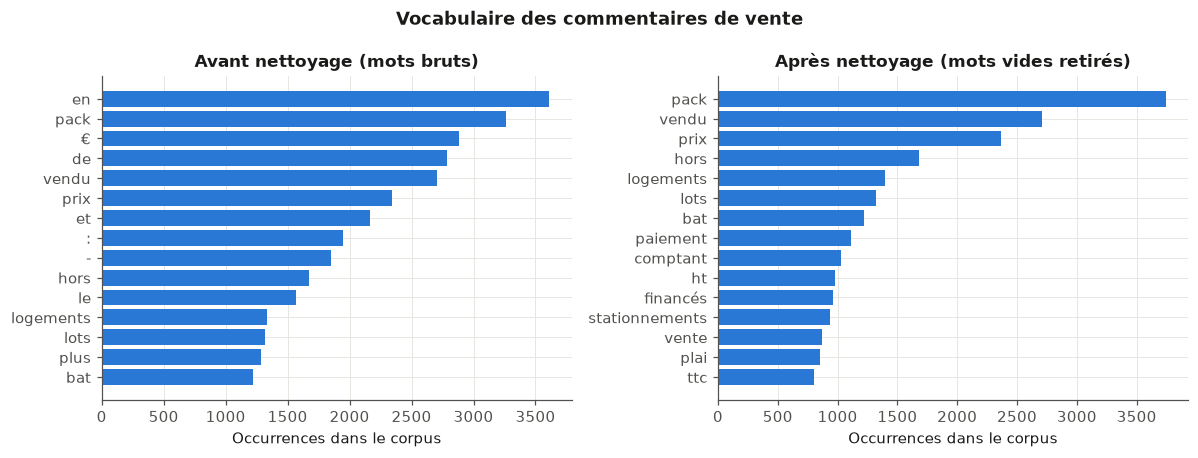

In [4]:

# Mots les plus fréquents avant / après nettoyage
from collections import Counter

brut = Counter(m for t in corpus["commentaire_vente"]
               for m in t.lower().split())
propre = Counter(m for t in corpus["commentaire_vente"] for m in jetons(t))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=False)
for ax, cpt, titre in [(axes[0], brut, "Avant nettoyage (mots bruts)"),
                       (axes[1], propre, "Après nettoyage (mots vides retirés)")]:
    top = pd.Series(dict(cpt.most_common(15))).iloc[::-1]
    ax.barh(top.index, top.values, color=theme_viz.SERIES[0])
    ax.set_title(titre)
    ax.set_xlabel("Occurrences dans le corpus")
fig.suptitle("Vocabulaire des commentaires de vente", fontweight="bold")
fig.tight_layout()
plt.show()



**Lecture.** Avant nettoyage, le classement est dominé par les mots
grammaticaux (« de », « en », « le »...) qui ne disent rien du dossier —
exactement le problème du *simple word count* pointé par le cours (slides
5-6 : *« Common words dominate »*). Après nettoyage émerge le **lexique
métier** : « pack », « prix », « frais », « notaire », « offerts »,
« vendu », « lots »... — la langue des remises commerciales et des
conditions de vente. C'est ce vocabulaire que TF-IDF va pondérer.



## 3. TF-IDF : d'abord à la main, puis avec scikit-learn

### 3.1 Les formules exactes du cours *(text retrieval, slide 7)*

> **TF-IDF = Term Frequency × Inverse Document Frequency**
>
> $$TF(t,d) = \frac{\text{count of term } t \text{ in document } d}{\text{total terms in document } d}$$
>
> $$IDF(t) = \log\left(\frac{\text{total documents}}{\text{documents containing term } t}\right)$$
>
> $$\text{TF-IDF}(t,d) = TF(t,d) \times IDF(t)$$
>
> *« Intuition: Rare words get higher scores, common words get lower scores. »*

L'exemple chiffré du cours (slide 8) donne $IDF = \log(3/2) = 0{,}18$ :
le logarithme du cours est donc le **logarithme décimal** ($\log_{10}$),
que nous reprenons ici. Le « nombre total de termes du document » est
compté **après** prétraitement (jetons hors mots vides).

Nous appliquons ces formules **à la main** sur un mini-corpus de trois
commentaires réels courts, choisis pour illustrer les deux effets : un mot
partagé (« prêt ») et un mot répété (« prix »).


In [5]:

mini = ["Refus de prêt : annulation à venir",
        "Dossier de prêt refusé, en cours d'annulation",
        "Vendu sans Pack \nPrix avant remise : 152 400 € \nPrix après remise : 130 000 €"]
# Vérification : ces trois commentaires existent bien dans la base
for d in mini:
    assert (corpus["commentaire_vente"] == d).any(), d
mini_jetons = [jetons(d) for d in mini]
for i, (d, js) in enumerate(zip(mini, mini_jetons), 1):
    print(f"d{i} : {d!r}")
    print(f"     jetons ({len(js)}) : {js}\n")


d1 : 'Refus de prêt : annulation à venir'
     jetons (4) : ['refus', 'prêt', 'annulation', 'venir']

d2 : "Dossier de prêt refusé, en cours d'annulation"
     jetons (5) : ['dossier', 'prêt', 'refusé', 'cours', 'annulation']

d3 : 'Vendu sans Pack \nPrix avant remise : 152 400 € \nPrix après remise : 130 000 €'
     jetons (8) : ['vendu', 'pack', 'prix', 'avant', 'remise', 'prix', 'après', 'remise']



In [6]:

# Application manuelle des formules du cours (slide 7), log décimal (slide 8)
from collections import Counter

N = len(mini_jetons)                        # nombre total de documents
vocab = sorted(set(m for js in mini_jetons for m in js))
df = {t: sum(t in js for js in mini_jetons) for t in vocab}
idf = {t: np.log10(N / df[t]) for t in vocab}          # IDF(t) = log(N / df_t)

lignes = []
for t in vocab:
    ligne = {"terme": t, "df(t)": df[t], "IDF(t)": round(idf[t], 3)}
    for i, js in enumerate(mini_jetons, 1):
        tf = Counter(js)[t] / len(js)                  # TF(t,d) = count / total
        ligne[f"TF d{i}"] = round(tf, 3)
        ligne[f"TF-IDF d{i}"] = round(tf * idf[t], 3)  # TF-IDF = TF x IDF
    lignes.append(ligne)
tfidf_main = pd.DataFrame(lignes).set_index("terme")

print("Calcul détaillé pour deux termes de d3 (6 jetons) :")
print(f"  'prix'  : TF = 2/6 = {2/6:.3f} ; IDF = log10(3/1) = {np.log10(3):.3f}"
      f" ; TF-IDF = {2/6 * np.log10(3):.3f}")
print(f"  'prêt' (dans d1, 4 jetons) : TF = 1/4 = {1/4:.3f} ;"
      f" IDF = log10(3/2) = {np.log10(3/2):.3f}"
      f" ; TF-IDF = {1/4 * np.log10(3/2):.3f}")
tfidf_main


Calcul détaillé pour deux termes de d3 (6 jetons) :
  'prix'  : TF = 2/6 = 0.333 ; IDF = log10(3/1) = 0.477 ; TF-IDF = 0.159
  'prêt' (dans d1, 4 jetons) : TF = 1/4 = 0.250 ; IDF = log10(3/2) = 0.176 ; TF-IDF = 0.044


,df(t),IDF(t),TF d1,TF-IDF d1,TF d2,TF-IDF d2,TF d3,TF-IDF d3
terme,,,,,,,,
annulation,2,0.176,0.25,0.044,0.2,0.035,0.000,0.000
après,1,0.477,0.00,0.000,0.0,0.000,0.125,0.060
avant,1,0.477,0.00,0.000,0.0,0.000,0.125,0.060
cours,1,0.477,0.00,0.000,0.2,0.095,0.000,0.000
dossier,1,0.477,0.00,0.000,0.2,0.095,0.000,0.000
pack,1,0.477,0.00,0.000,0.0,0.000,0.125,0.060
prix,1,0.477,0.00,0.000,0.0,0.000,0.250,0.119
prêt,2,0.176,0.25,0.044,0.2,0.035,0.000,0.000
refus,1,0.477,0.25,0.119,0.0,0.000,0.000,0.000



**Lecture.** Les deux effets annoncés par le cours se voient dans la
table : « prêt » et « annulation », présents dans **2 documents sur 3**,
reçoivent l'IDF faible $\log_{10}(3/2) = 0{,}176$ — mots partagés, peu
discriminants dans ce mini-corpus ; « prix », **répété deux fois** dans d3
et présent nulle part ailleurs, cumule un TF élevé ($2/6$) et l'IDF
maximal ($\log_{10} 3 = 0{,}477$) : c'est le terme au score le plus fort
(0,159). *« Rare words get higher scores, common words get lower scores »*
(slide 7).

### 3.2 Passage à l'échelle avec `TfidfVectorizer` — et un point d'honnêteté

Sur les ~9 700 commentaires, nous utilisons `TfidfVectorizer` de
scikit-learn. **Attention** : scikit-learn n'implémente pas exactement la
formule du cours. Il utilise un IDF **lissé** en logarithme népérien,
$IDF_{sk}(t) = \ln\frac{1 + N}{1 + df(t)} + 1$ (le lissage évite les
divisions par zéro et le $+1$ empêche d'annuler totalement un terme
présent partout), un TF en **comptage brut** (non divisé par la longueur)
et une **normalisation L2** finale de chaque vecteur document. L'esprit
est le même (pénaliser les mots fréquents dans tout le corpus), les
valeurs diffèrent — nous le vérifions numériquement ci-dessous.


In [7]:

from sklearn.feature_extraction.text import TfidfVectorizer

# Corpus dédupliqué pour la recherche : certains commentaires standard
# ("60 Logements, soit 35 sur bat A...") sont recopiés sur tous les lots
# d'une même opération et satureraient les résultats.
docs = corpus.drop_duplicates(subset="texte").reset_index(drop=True)
vectoriseur = TfidfVectorizer(preprocessor=nettoyer, stop_words=MOTS_VIDES,
                              min_df=2)
X_tfidf = vectoriseur.fit_transform(docs["texte"])
print(f"Matrice TF-IDF : {X_tfidf.shape[0]} documents x "
      f"{X_tfidf.shape[1]} termes "
      f"(creuse à {100 * (1 - X_tfidf.nnz / np.prod(X_tfidf.shape)):.2f} %)")

# Vérification de l'écart cours / scikit-learn sur le terme 'notaire'
t = "notaire"
df_t = int((X_tfidf[:, vectoriseur.vocabulary_[t]] > 0).sum())
N_docs = X_tfidf.shape[0]
idf_cours = np.log10(N_docs / df_t)
idf_sk = vectoriseur.idf_[vectoriseur.vocabulary_[t]]
print(f"\nTerme {t!r} : présent dans {df_t} des {N_docs} documents")
print(f"  IDF formule du cours (log10)      : {idf_cours:.3f}")
print(f"  IDF scikit-learn (ln lissé, +1)   : {idf_sk:.3f}")
print("Les échelles diffèrent, le classement des termes reste le même.")


Matrice TF-IDF : 1346 documents x 535 termes (creuse à 98.81 %)

Terme 'notaire' : présent dans 166 des 1346 documents
  IDF formule du cours (log10)      : 0.909
  IDF scikit-learn (ln lissé, +1)   : 3.088
Les échelles diffèrent, le classement des termes reste le même.



## 4. Similarité cosinus et moteur de recherche de dossiers semblables

### 4.1 La formule du cours *(text retrieval, slide 12)*

> $$\cos(\theta) = \frac{\mathbf{A}\cdot\mathbf{B}}{|\mathbf{A}|\times|\mathbf{B}|} = \frac{\sum_{i=1}^n A_i B_i}{\sqrt{\sum_{i=1}^n A_i^2} \times \sqrt{\sum_{i=1}^n B_i^2}}$$
>
> *« Range: $[-1, 1]$ »* ; *« Cosine similarity ignores magnitude, only
> cares about direction »* (slide 13).

Vérifions-la à la main sur les vecteurs TF-IDF de d1 et d2 du mini-corpus,
qui ne partagent que « prêt » et « annulation ».


In [8]:

def vecteur(i: int) -> np.ndarray:
    return tfidf_main[f"TF-IDF d{i}"].to_numpy(dtype=float)

A, B = vecteur(1), vecteur(2)
num = float(A @ B)                                   # somme des A_i * B_i
nA, nB = float(np.sqrt(A @ A)), float(np.sqrt(B @ B))
print("cos(theta) = A.B / (|A| x |B|)")
print(f"           = {num:.5f} / ({nA:.4f} x {nB:.4f}) = {num / (nA * nB):.3f}")
A3 = vecteur(3)
print(f"cos(d1, d3) = {float(A @ A3):.3f} (aucun terme commun -> orthogonaux)")


cos(theta) = A.B / (|A| x |B|)
           = 0.00308 / (0.1794 x 0.1718) = 0.100
cos(d1, d3) = 0.000 (aucun terme commun -> orthogonaux)



**Lecture.** d1 et d2 racontent la même histoire (un refus de prêt qui
mène à une annulation) avec des mots différents : leur similarité cosinus
est modérée mais strictement positive, portée par les deux termes
partagés. d1 et d3 (remise de prix) n'ont **aucun** terme commun : cosinus
nul, vecteurs orthogonaux. Sur des vecteurs TF-IDF (positifs), la
similarité vit dans $[0, 1]$.

### 4.2 Le pipeline de recherche *(text retrieval, slides 20-21)*

Le cours prescrit quatre étapes : *« 1. Convert query to vector ;
2. Calculate similarity with all documents ; 3. Rank by similarity score ;
4. Return top documents »*. C'est le **moteur de recherche interne** du
copilote : un responsable de programme tape une requête métier et
retrouve les dossiers au commentaire semblable — l'usage recommandé par le
cours (slide 18 : *« Most common in text retrieval: cosine similarity with
TF-IDF »*).


In [9]:

from sklearn.metrics.pairwise import cosine_similarity

def chercher(requete: str, k: int = 5) -> pd.DataFrame:
    """Pipeline slides 20-21 : requête -> vecteur -> similarités -> tri -> top k."""
    q = vectoriseur.transform([requete])             # 1. query -> vecteur
    sims = cosine_similarity(q, X_tfidf).ravel()     # 2. similarité avec tous
    top = np.argsort(sims)[::-1][:k]                 # 3. tri par score
    return pd.DataFrame({                            # 4. top documents
        "cosinus": sims[top].round(3),
        "désisté": docs["desiste"].iloc[top].to_numpy(),
        "commentaire": [c[:90] for c in docs["commentaire_vente"].iloc[top]],
    })

print("Requête 1 : « refus de prêt banque »")
chercher("refus de prêt banque")


Requête 1 : « refus de prêt banque »


,cosinus,désisté,commentaire
0,0.895,1,Refus de prêt : annulation à venir
1,0.747,1,Refus de prêt : Dossier en cours d'annulation
2,0.747,1,Dossier en cours d'annulation : refus de prêt
3,0.705,1,Refus de prêt : dos en cours d'annulation
4,0.675,1,Refus de prêt par organismes financiers \nCour...


In [10]:

print("Requête 2 : « remise prix hors pack »")
chercher("remise prix hors pack")


Requête 2 : « remise prix hors pack »


,cosinus,désisté,commentaire
0,0.786,0,PRIX HORS PACK 156000 -
1,0.712,0,Prix hors Pack : 205 000 € \nVendu Prix Pack :...
2,0.712,0,Vendu prix Pack : 248 292 € \nPrix hors Pack :...
3,0.682,1,Vendu au prix HORS PACK : 179 000 €
4,0.682,0,Vendu prix HORS PACK : 320 000 €



**Lecture.** Les deux requêtes métier de B-T1 fonctionnent : « refus de
prêt banque » remonte des dossiers **tous désistés** (cosinus 0,68 à
0,90), où le commentaire signalait le refus *avant* la fin du dossier ;
« remise prix hors pack » remonte des ventes **maintenues** documentant
des remises invisibles des champs structurés (« prix avant remise
152 400 € / après remise 130 000 € »). Le moteur transforme donc le champ
libre en outil d'investigation : retrouver les précédents comparables, ou
auditer les pratiques de remise d'une agence.



## 5. Prédire le désistement à partir du texte — Naive Bayes

### 5.1 Un classifieur absent des cours, à ne pas confondre avec $h^*$

Le classifieur **Naive Bayes n'est traité par aucun des cours** du
master : nous l'introduisons d'après C.-A. Azencott, *Introduction au
Machine Learning* (Dunod), la référence bibliographique des cours de
classification (cf. *coursClassif-3ArbresDecision*, slide 22).

Attention à un faux ami signalé par notre relecture des cours : le
« **classifieur de Bayes** » de *course.pdf* (théorème 1.1, p. 3),

$$h^*(x) = \begin{cases} 1 & \text{si } \eta(x) \ge \tfrac{1}{2} \\ 0 & \text{sinon}\end{cases}
\qquad \eta(x) = P(Y = 1 \mid X = x),$$

est le prédicteur **optimal théorique**, calculable seulement si l'on
connaît la vraie loi $P_{X,Y}$ — c'est une borne, pas un algorithme.
**Naive Bayes**, lui, est un algorithme qui **estime** $\eta(x)$ en
retournant la formule de Bayes :

$$P(Y = k \mid x) = \frac{P(Y = k)\, P(x \mid Y = k)}{P(x)},$$

puis en rendant le calcul de $P(x \mid Y = k)$ possible par l'hypothèse
**« naïve » d'indépendance conditionnelle** des termes sachant la classe :
pour un document représenté par ses comptages de termes
$x = (x_1, \dots, x_{|V|})$ (modèle **multinomial**),

$$P(x \mid Y = k) \propto \prod_{t=1}^{|V|} \theta_{kt}^{\,x_t},
\qquad \hat{y}(x) = \arg\max_k \Big[\log P(Y = k) + \sum_t x_t \log \theta_{kt}\Big].$$

L'hypothèse est évidemment fausse (« refus » et « prêt » sont corrélés)
mais rend l'estimation possible avec très peu de paramètres. Les
probabilités de termes sont estimées avec le **lissage de Laplace**
($\alpha = 1$), qui évite qu'un terme jamais vu dans une classe
n'annule tout le produit :

$$\hat{\theta}_{kt} = \frac{N_{kt} + \alpha}{N_k + \alpha\,|V|}.$$

Si Naive Bayes estimait parfaitement $\eta(x)$, il **coïnciderait** avec
$h^*$ ; en pratique l'indépendance conditionnelle est violée, donc il
n'atteint pas le risque de Bayes $R^*$ — c'est précisément la différence
entre l'algorithme et l'optimum théorique.

### 5.2 Anti-fuite : retirer les commentaires qui *racontent* le désistement

La cible est `desiste`. Or beaucoup de commentaires sont mis à jour
**après** l'événement (« Refus de prêt : annulation à venir ») : les mots
« désistement », « désisté », « annulation », « annulé », « résiliation »,
« résolution » sont des **copies textuelles de la cible**, pas des signaux
précoces — la **fuite de cible** contre laquelle le cours d'EDA met en
garde (p. 7). Un modèle entraîné avec eux « prédirait » le passé. Nous
retirons donc les documents contenant ces mots et apprenons sur le reste :
la question devient *« un commentaire qui ne dit pas explicitement l'issue
du dossier porte-t-il quand même un signal ? »*.


In [11]:

MOTS_FUITE = ["désist", "desist", "annul", "résili", "resili", "résolu", "resolu"]
fuite = corpus["texte"].str.contains("|".join(MOTS_FUITE))
print(f"Commentaires mentionnant explicitement le désistement : {fuite.sum()}")
print(f"  -> taux de désistement parmi eux : {corpus.loc[fuite, 'desiste'].mean():.1%}"
      "  (les garder rendrait la « prédiction » triviale et fausse)")
appr = corpus.loc[~fuite].copy()
print(f"Corpus d'apprentissage : {len(appr)} commentaires, "
      f"taux de désistement {appr['desiste'].mean():.1%} (classes déséquilibrées)")


Commentaires mentionnant explicitement le désistement : 314
  -> taux de désistement parmi eux : 98.4%  (les garder rendrait la « prédiction » triviale et fausse)
Corpus d'apprentissage : 9374 commentaires, taux de désistement 12.7% (classes déséquilibrées)



### 5.3 Entraînement et évaluation

Protocole conforme aux recommandations du cours d'EDA (p. 7-8) : split
**stratifié** (le désistement ne pèse que ~13 %), métrique **F1** de la
classe minoritaire plutôt qu'exactitude, et deux points de comparaison —
la **baseline majoritaire** (prédire « maintenu » partout) et une
**régression logistique** (perte logistique du cours *course.pdf*,
p. 32-35) sur les mêmes comptages. Naive Bayes multinomial travaille sur
les **comptages bruts** (c'est son modèle génératif : des tirages de mots),
pas sur le TF-IDF qui en casserait l'interprétation probabiliste.


In [12]:

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

X_txt, y = appr["texte"], appr["desiste"]
X_tr, X_te, y_tr, y_te = train_test_split(X_txt, y, test_size=0.25,
                                          stratify=y, random_state=42)
compteur = CountVectorizer(preprocessor=nettoyer, stop_words=MOTS_VIDES, min_df=3)
M_tr = compteur.fit_transform(X_tr)
M_te = compteur.transform(X_te)
print(f"Vocabulaire : {M_tr.shape[1]} termes (min_df=3) ; "
      f"train {M_tr.shape[0]} docs, test {M_te.shape[0]} docs")

modeles = {
    "baseline majoritaire": DummyClassifier(strategy="most_frequent"),
    "Naive Bayes multinomial (alpha=1)": MultinomialNB(alpha=1.0),
    "régression logistique": LogisticRegression(max_iter=1000, random_state=42),
}
resultats, preds = [], {}
for nom, m in modeles.items():
    m.fit(M_tr, y_tr)
    p = m.predict(M_te)
    preds[nom] = p
    resultats.append({
        "modèle": nom,
        "F1 (désisté)": round(f1_score(y_te, p, zero_division=0), 3),
        "précision": round(precision_score(y_te, p, zero_division=0), 3),
        "rappel": round(recall_score(y_te, p, zero_division=0), 3),
        "exactitude": round((p == y_te).mean(), 3),
    })
pd.DataFrame(resultats).set_index("modèle")


Vocabulaire : 599 termes (min_df=3) ; train 7030 docs, test 2344 docs


,F1 (désisté),précision,rappel,exactitude
modèle,,,,
baseline majoritaire,0.000,0.000,0.000,0.873
Naive Bayes multinomial (alpha=1),0.343,0.260,0.503,0.755
régression logistique,0.254,0.719,0.154,0.885


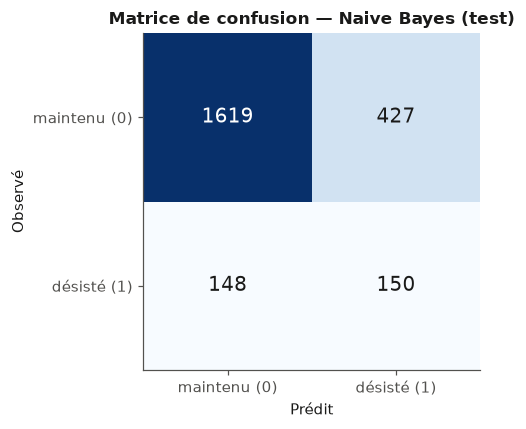

In [13]:

cm = confusion_matrix(y_te, preds["Naive Bayes multinomial (alpha=1)"])
fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(cm, cmap=theme_viz.CMAP_SEQ)
etiquettes = ["maintenu (0)", "désisté (1)"]
ax.set_xticks([0, 1], etiquettes)
ax.set_yticks([0, 1], etiquettes)
ax.set_xlabel("Prédit")
ax.set_ylabel("Observé")
ax.set_title("Matrice de confusion — Naive Bayes (test)")
for i in range(2):
    for j in range(2):
        couleur = "white" if cm[i, j] > cm.max() / 2 else theme_viz.ENCRE
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                fontsize=13, color=couleur)
ax.grid(False)
fig.tight_layout()
plt.show()



**Lecture.** Sur le jeu de test (2 344 dossiers), Naive Bayes obtient
**F1 ≈ 0,35** (rappel 0,50, précision 0,26) : il retrouve la moitié des
désistements réels au prix d'une alerte sur ~24 % des dossiers. La
**baseline majoritaire a un F1 de 0** (elle ne détecte aucun désistement —
son exactitude de 87 % illustre pourquoi l'exactitude est trompeuse sur
classes déséquilibrées). La **régression logistique fait moins bien en
F1 (≈ 0,24)** : plus précise (0,63) mais quasi muette (rappel 0,15), elle
sur-pénalise la classe rare ; le prior de classes et le lissage de Naive
Bayes le rendent plus généreux en rappel — préférable pour un système
d'**alerte précoce** où manquer un désistement coûte plus cher qu'une
fausse alerte.


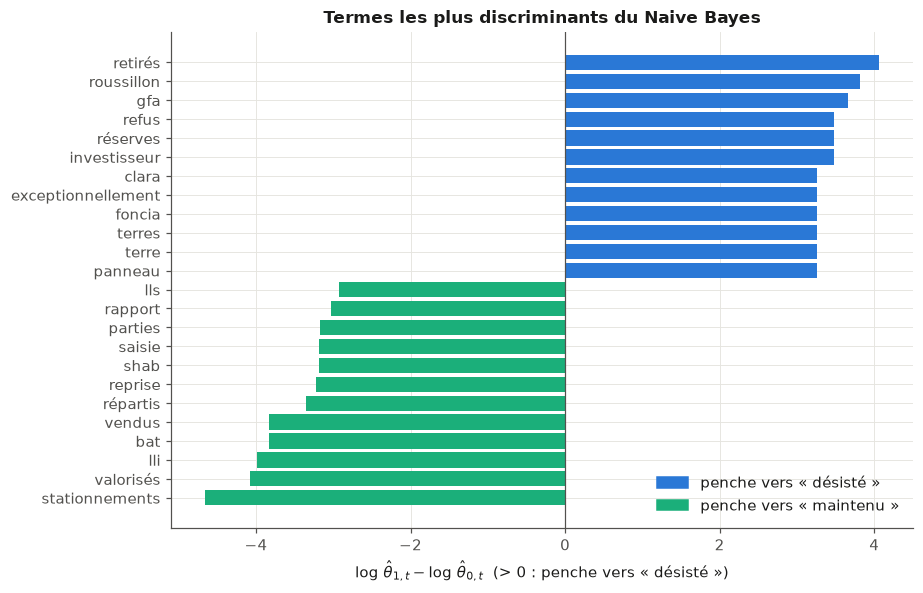

In [14]:

# Mots les plus discriminants : log-ratio des probabilités de termes
# log(theta_{1,t} / theta_{0,t}) avec lissage de Laplace (alpha=1)
nb = modeles["Naive Bayes multinomial (alpha=1)"]
termes = np.array(compteur.get_feature_names_out())
log_ratio = nb.feature_log_prob_[1] - nb.feature_log_prob_[0]
ordre = np.argsort(log_ratio)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
haut = ordre[-12:]                       # penche vers « désisté »
bas = ordre[:12][::-1]                   # penche vers « maintenu »
y_pos = np.arange(24)
valeurs = np.concatenate([log_ratio[bas][::-1], log_ratio[haut]])
noms = np.concatenate([termes[bas][::-1], termes[haut]])
couleurs = [theme_viz.SERIES[1]] * 12 + [theme_viz.SERIES[0]] * 12
ax.barh(y_pos, valeurs, color=couleurs)
ax.set_yticks(y_pos, noms)
ax.axvline(0, color=theme_viz.ENCRE_2, linewidth=0.8)
ax.set_xlabel(r"$\log\,\hat{\theta}_{1,t} - \log\,\hat{\theta}_{0,t}$"
              "  (> 0 : penche vers « désisté »)")
ax.set_title("Termes les plus discriminants du Naive Bayes")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=theme_viz.SERIES[0], label="penche vers « désisté »"),
                   Patch(color=theme_viz.SERIES[1], label="penche vers « maintenu »")],
          frameon=False, loc="lower right")
fig.tight_layout()
plt.show()



**Lecture — et honnêteté sur la force du signal.** Les termes qui penchent
vers « désisté » sont cohérents avec le métier : **« refus »** (de prêt,
avant que l'annulation soit actée), **« retirés »** (plis SRU non retirés,
prélude à la rétractation), **« réserves »/« investisseur »** (dossiers
sous conditions), et des canaux d'origine (« panneau », « site ») typiques
de prospects moins engagés. Côté « maintenu » : le vocabulaire des ventes
en bloc et du logement social (« lls », « lli », « bat », « répartis »,
« pkgs »), quasi jamais désistées.

Il faut cependant le dire clairement : **le signal est faible**
(F1 ≈ 0,35). Trois raisons structurelles : (1) la plupart des commentaires
sont écrits **à la réservation** et décrivent les conditions de vente, pas
la fragilité du client ; (2) beaucoup de désistements (rétractation légale
dans les 10 jours) n'ont **aucun précurseur textuel possible** ; (3) le
champ est rempli de façon hétérogène selon les agences. Le texte seul ne
suffit donc pas à prédire le désistement — il vaut comme **signal
d'appoint** : la probabilité Naive Bayes deviendra une *feature*
supplémentaire du score de risque de l'axe A, pas un prédicteur autonome.



## 6. Entropie et divergence KL : quelle agence a un profil de désistement atypique ?

L'**entropie** vient du cours d'arbres de décision
(*coursClassif-3ArbresDecision*, slide 16) comme critère d'impureté d'une
région $R$, avec $p_k$ la proportion de la classe $k$ :

$$\mathcal{I}_{\mathcal{E}}(R) = -\sum_k p_k \log_2(p_k).$$

Appliquée à la distribution des **motifs de désistement** d'une agence,
elle mesure en **bits** la diversité de ses motifs : proche de 0, un motif
unique domine ; proche de $\log_2 K$, tous les motifs sont équiprobables.

La **divergence de Kullback-Leibler est absente des neuf cours**
(cf. notre relevé `docs/reference_cours.md`, annexe A) ; nous l'introduisons
d'après une source externe (S. Kullback & R. A. Leibler, 1951 ;
présentation moderne dans Azencott, *Introduction au Machine Learning*,
la référence des cours de classification), en base 2 pour rester homogène
avec l'entropie du cours :

$$D_{KL}(P \,\|\, Q) = \sum_k p_k \log_2 \frac{p_k}{q_k} \;\ge\; 0,
\qquad D_{KL}(P \,\|\, Q) = 0 \iff P = Q.$$

Elle mesure (en bits) le coût d'encoder les motifs de l'agence ($P$) avec
le code optimal du groupe ($Q$) : plus elle est grande, plus le profil de
l'agence s'écarte du profil groupe. Elle est asymétrique et finie ici car
$q_k > 0$ pour tout motif observé.

Les libellés de motifs étant hétérogènes (« Refus de prêt » vs « Pb
financement / refus prêt », « Rétractation » vs « Rétractation dans les
10 jours »), nous les harmonisons d'abord en **quatre familles** ; les
agences sont agrégées sur leur ville (les préfixes « AMENAGEMENT / »
désignent la même implantation).


In [15]:

motifs = ventes.dropna(subset=["motif_desistement"]).merge(
    operations[["id_operation", "agence"]], on="id_operation")
motifs["agence"] = (motifs["agence"].str.replace("AMENAGEMENT / ", "", regex=False)
                    .str.strip())

def famille_motif(m: str) -> str:
    m = m.lower()
    if "prêt" in m or "financement" in m or "revente" in m:
        return "Financement (refus de prêt, non-revente)"
    if "rétractation" in m or "sru" in m:
        return "Rétractation (délai légal)"
    if any(k in m for k in ["divorce", "décès", "emploi", "mutation", "situation"]):
        return "Aléa personnel"
    return "Autres motifs"

motifs["famille"] = motifs["motif_desistement"].map(famille_motif)
tab = (motifs.groupby("agence")["famille"].value_counts().unstack(fill_value=0))
tab = tab.loc[tab.sum(axis=1) >= 50]      # agences à effectif interprétable
FAMILLES = ["Financement (refus de prêt, non-revente)", "Rétractation (délai légal)",
            "Aléa personnel", "Autres motifs"]
tab = tab[FAMILLES]
print(f"{motifs['famille'].value_counts().to_string()}\n")
print(f"Agences retenues (>= 50 motifs) : {len(tab)}")
tab


famille
Financement (refus de prêt, non-revente)    1030
Rétractation (délai légal)                   699
Autres motifs                                141
Aléa personnel                                93

Agences retenues (>= 50 motifs) : 5


famille,"Financement (refus de prêt, non-revente)",Rétractation (délai légal),Aléa personnel,Autres motifs
agence,,,,
Agence Béziers,628,347,46,42
Agence Montpellier,144,148,13,2
Agence Perpignan,211,150,20,7
Agence Salon-de-Provence,10,0,0,90
Agence Toulouse,37,54,14,0


In [16]:

P = tab.div(tab.sum(axis=1), axis=0)              # P : distribution par agence
q = tab.sum(axis=0) / tab.sum(axis=0).sum()       # Q : distribution groupe

def entropie(p: np.ndarray) -> float:
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())          # I_E = -Σ p_k log2 p_k

def kl(p: np.ndarray, q_: np.ndarray) -> float:
    m = p > 0
    return float((p[m] * np.log2(p[m] / q_[m])).sum())   # Σ p_k log2(p_k/q_k)

profil = pd.DataFrame({
    "n motifs": tab.sum(axis=1),
    "entropie (bits)": [round(entropie(P.loc[a].to_numpy()), 3) for a in P.index],
    "KL vs groupe (bits)": [round(kl(P.loc[a].to_numpy(), q.to_numpy()), 3)
                            for a in P.index],
}).sort_values("KL vs groupe (bits)", ascending=False)
print(f"Entropie du profil groupe : {entropie(q.to_numpy()):.3f} bits "
      f"(max possible log2(4) = 2)")
profil


Entropie du profil groupe : 1.500 bits (max possible log2(4) = 2)


,n motifs,entropie (bits),KL vs groupe (bits)
agence,,,
Agence Salon-de-Provence,100,0.469,3.043
Agence Toulouse,105,1.411,0.269
Agence Montpellier,307,1.260,0.105
Agence Perpignan,388,1.333,0.044
Agence Béziers,1063,1.356,0.020


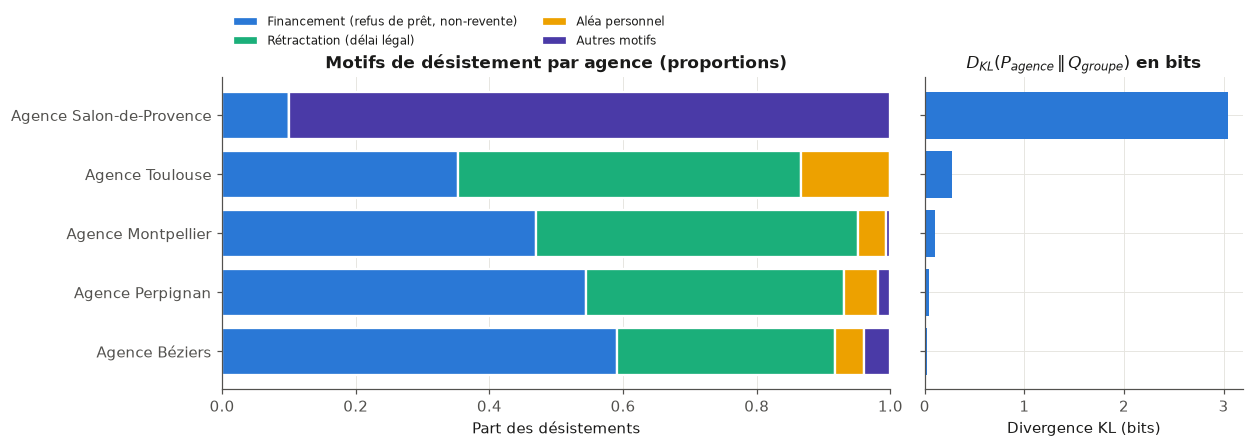

In [17]:

ordre_ag = profil.index[::-1]                      # tri par KL croissant
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True,
                         gridspec_kw={"width_ratios": [2.1, 1]})
gauche = np.zeros(len(ordre_ag))
for i, fam in enumerate(FAMILLES):
    v = P.loc[ordre_ag, fam].to_numpy()
    axes[0].barh(ordre_ag, v, left=gauche, color=theme_viz.SERIES[i],
                 label=fam, edgecolor="white", linewidth=1.5)
    gauche += v
axes[0].set_title("Motifs de désistement par agence (proportions)")
axes[0].set_xlabel("Part des désistements")
axes[0].set_xlim(0, 1)
axes[0].legend(frameon=False, fontsize=8, loc="lower left",
               bbox_to_anchor=(0, 1.06), ncols=2)

axes[1].barh(ordre_ag, profil.loc[ordre_ag, "KL vs groupe (bits)"],
             color=theme_viz.SERIES[0])
axes[1].set_title(r"$D_{KL}(P_{agence}\,\|\,Q_{groupe})$ en bits")
axes[1].set_xlabel("Divergence KL (bits)")
fig.tight_layout()
plt.show()



**Lecture.** L'agence au profil **le plus atypique est de très loin
Salon-de-Provence** : $D_{KL} \approx 3{,}0$ bits contre moins de 0,3 bit
pour toutes les autres, avec une entropie effondrée (0,47 bit contre
1,26-1,41 ailleurs, et 1,50 pour le groupe). La raison se lit dans la
table : **90 % de ses motifs sont « Autres motifs »** — non pas un
comportement client différent, mais très probablement un **défaut de
saisie** (le motif n'est pas renseigné finement dans cette agence). C'est
un enseignement métier en soi : avant d'être un signal commercial, la KL
est ici un **détecteur de qualité de données** — le copilote signalera
cette agence pour fiabiliser la saisie, sans quoi ses désistements
resteront inanalysables. Derrière elle, Toulouse (KL ≈ 0,27 :
sur-représentation de la rétractation légale, 51 % de ses motifs contre
36 % au niveau groupe) et Montpellier (KL ≈ 0,11) s'écartent modérément du
profil groupe, dominé par le refus de prêt (~53 %) puis la rétractation
légale (~36 %).



## 7. Le réseau de commercialisation *(module analyse de réseaux sociaux)*

Ce module du master n'ayant **pas de support PDF** dans `Cours/`, nous
utilisons le formalisme standard de l'analyse de réseaux (M. E. J. Newman,
*Networks*, 2ᵉ éd., Oxford University Press, 2018) :

- **graphe biparti** vendeurs ↔ opérations : une arête relie le vendeur
  $v$ à l'opération $o$ s'il y a signé au moins un dossier, pondérée par
  le nombre de dossiers ;
- **centralité de degré** (Newman, §7.1) : $C_D(v) = \frac{k_v}{n - 1}$,
  part des autres vendeurs avec qui $v$ partage au moins une opération
  (sur la projection) ;
- **centralité d'intermédiarité** (*betweenness*, Freeman 1977 ; Newman,
  §7.7) : $C_B(v) = \sum_{s \ne v \ne t} \frac{\sigma_{st}(v)}{\sigma_{st}}$,
  part des plus courts chemins passant par $v$ — les « ponts » entre
  sous-marchés ;
- **communautés par modularité** (Newman, §14) :
  $Q = \frac{1}{2m}\sum_{ij}\left(A_{ij} - \frac{k_i k_j}{2m}\right)\delta(c_i, c_j)$,
  maximisée par l'algorithme glouton de Clauset-Newman-Moore (2004),
  implémenté dans `networkx` (`greedy_modularity_communities`).

Précision honnête sur la donnée : `nom_vendeur` (22 % manquant) désigne le
plus souvent une **entité commerciale** (réseau interne « ANGELOTTI
PROMOTION », prescripteurs externes comme « VALORICIEL » ou « AFEDIM »),
parfois une personne. Le « réseau social » est donc celui des
organisations de vente. Pour la lisibilité, nous filtrons les vendeurs à
**au moins 3 dossiers**.


In [18]:

import networkx as nx
from networkx.algorithms import bipartite as nx_bip
from networkx.algorithms.community import greedy_modularity_communities

vd = ventes.dropna(subset=["nom_vendeur"]).copy()
nb_par_vendeur = vd["nom_vendeur"].value_counts()
actifs = nb_par_vendeur[nb_par_vendeur >= 3].index
aretes = (vd[vd["nom_vendeur"].isin(actifs)]
          .groupby(["nom_vendeur", "id_operation"])
          .agg(dossiers=("code_dossier", "count"), desistes=("desiste", "sum"))
          .reset_index())

B = nx.Graph()
B.add_nodes_from(aretes["nom_vendeur"].unique(), genre="vendeur")
B.add_nodes_from(("op_" + aretes["id_operation"].astype(str)).unique(), genre="operation")
for _, r in aretes.iterrows():
    B.add_edge(r["nom_vendeur"], f"op_{r['id_operation']}", weight=int(r["dossiers"]))

print(f"Vendeurs à >= 3 dossiers : {len(actifs)} sur {len(nb_par_vendeur)} "
      f"({vd['nom_vendeur'].isin(actifs).mean():.1%} des dossiers attribués)")
print(f"Graphe biparti : {B.number_of_nodes()} nœuds "
      f"({len(actifs)} vendeurs + {aretes['id_operation'].nunique()} opérations), "
      f"{B.number_of_edges()} arêtes, "
      f"{nx.number_connected_components(B)} composantes connexes")


Vendeurs à >= 3 dossiers : 209 sur 281 (98.8% des dossiers attribués)
Graphe biparti : 313 nœuds (209 vendeurs + 104 opérations), 711 arêtes, 5 composantes connexes


In [19]:

# Projection sur les vendeurs : deux vendeurs sont liés s'ils ont vendu
# dans la même opération (poids = nb d'opérations partagées)
vendeurs = [n for n, d in B.nodes(data=True) if d["genre"] == "vendeur"]
proj = nx_bip.weighted_projected_graph(B, vendeurs)
cdeg = nx.degree_centrality(proj)
cbet = nx.betweenness_centrality(proj, seed=42)
communautes = list(greedy_modularity_communities(proj, weight="weight"))

stats_v = vd.groupby("nom_vendeur").agg(dossiers=("code_dossier", "count"),
                                        tx_desist=("desiste", "mean"))
pivots = (pd.DataFrame({"centralité degré": cdeg, "intermédiarité": cbet})
          .join(stats_v).sort_values("intermédiarité", ascending=False))
pivots["tx_desist"] = pivots["tx_desist"].round(3)
print(f"Projection vendeurs : {proj.number_of_nodes()} nœuds, "
      f"{proj.number_of_edges()} arêtes")
print(f"Communautés (modularité gloutonne) : {len(communautes)} "
      f"de tailles {[len(c) for c in communautes]}")
pivots.head(8).round(3)


Projection vendeurs : 209 nœuds, 3266 arêtes
Communautés (modularité gloutonne) : 10 de tailles [74, 48, 46, 22, 12, 3, 1, 1, 1, 1]


,centralité degré,intermédiarité,dossiers,tx_desist
VALORICIEL,0.952,0.183,2033,0.296
ANGELOTTI PROMOTION,0.885,0.129,3808,0.090
AFEDIM,0.688,0.059,354,0.096
MEDICIS PATRIMOINE,0.639,0.055,77,0.104
NOVANEA,0.649,0.053,175,0.240
PATRI IMMO,0.615,0.041,225,0.164
IZIMMO,0.466,0.023,94,0.149
AS ET ASSOCIES,0.428,0.021,145,0.421


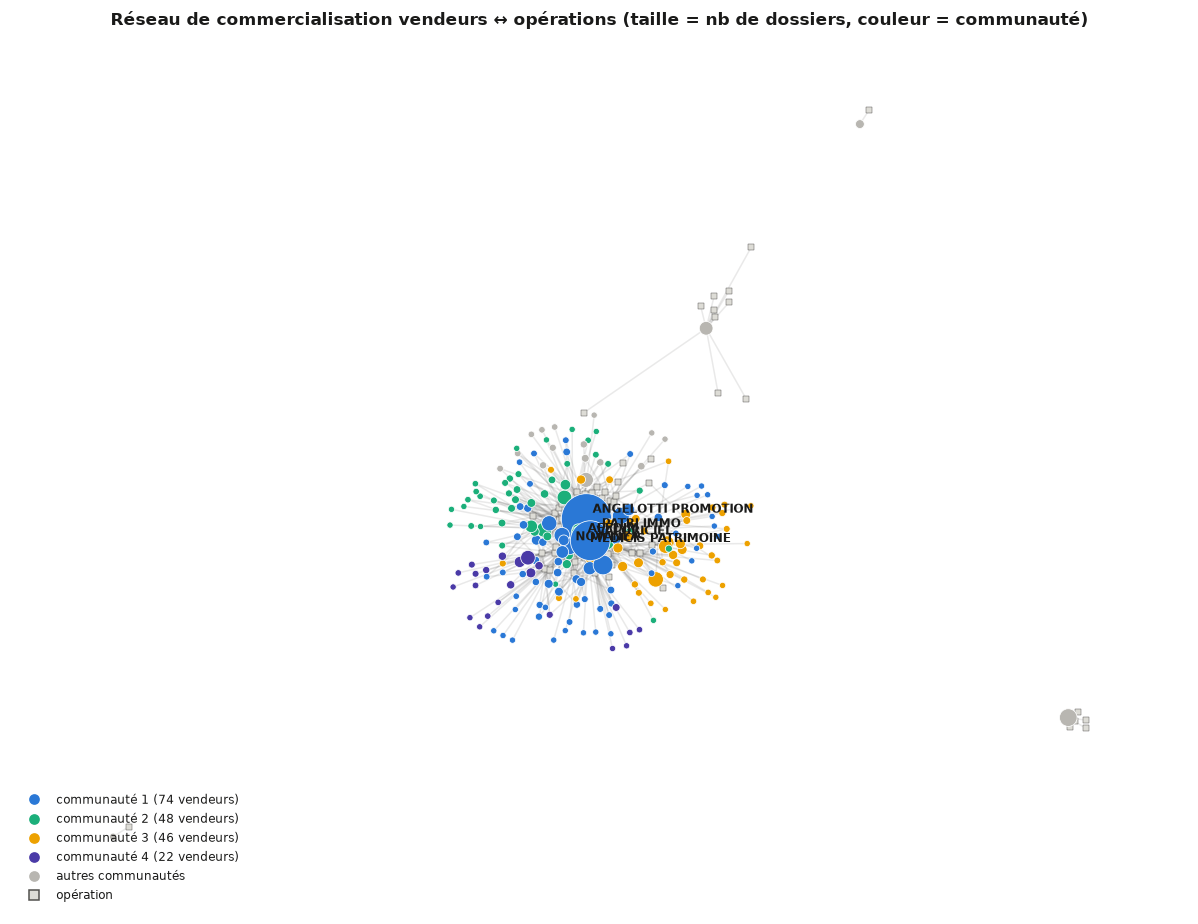

In [20]:

# Visualisation du graphe biparti : taille = nb de dossiers du vendeur,
# couleur = communauté (4 principales avec la palette, le reste en gris)
appartenance = {v: i for i, c in enumerate(communautes) for v in c}
GRIS = "#b8b6b1"
coul_comm = {i: (theme_viz.SERIES[i] if i < 4 else GRIS) for i in range(len(communautes))}
pos = nx.spring_layout(B, weight="weight", seed=42, k=0.11)

fig, ax = plt.subplots(figsize=(11, 8.5))
nx.draw_networkx_edges(B, pos, ax=ax, alpha=0.12, edge_color=theme_viz.ENCRE_2)
ops_n = [n for n, d in B.nodes(data=True) if d["genre"] == "operation"]
nx.draw_networkx_nodes(B, pos, nodelist=ops_n, node_shape="s", node_size=14,
                       node_color="#dddcd6", edgecolors=theme_viz.ENCRE_2,
                       linewidths=0.3, ax=ax)
tailles = [12 + 2.2 * stats_v.loc[v, "dossiers"] ** 0.75 for v in vendeurs]
couleurs_v = [coul_comm[appartenance[v]] for v in vendeurs]
nx.draw_networkx_nodes(B, pos, nodelist=vendeurs, node_size=tailles,
                       node_color=couleurs_v, edgecolors="white",
                       linewidths=0.5, ax=ax)
for v in pivots.head(6).index:
    ax.annotate(v, pos[v], fontsize=8, fontweight="bold",
                color=theme_viz.ENCRE, xytext=(4, 4), textcoords="offset points")
from matplotlib.lines import Line2D
legende = [Line2D([], [], marker="o", ls="", color=theme_viz.SERIES[i],
                  label=f"communauté {i + 1} ({len(communautes[i])} vendeurs)")
           for i in range(4)]
legende += [Line2D([], [], marker="o", ls="", color=GRIS, label="autres communautés"),
            Line2D([], [], marker="s", ls="", color="#dddcd6",
                   markeredgecolor=theme_viz.ENCRE_2, label="opération")]
ax.legend(handles=legende, frameon=False, fontsize=8, loc="lower left")
ax.set_title("Réseau de commercialisation vendeurs ↔ opérations "
             "(taille = nb de dossiers, couleur = communauté)")
ax.set_axis_off()
ax.grid(False)
fig.tight_layout()
plt.show()


In [21]:

# Dépendance commerciale : concentration des dossiers, et taux de
# désistement des vendeurs centraux (top 10 d'intermédiarité) vs périphériques
part_top2 = nb_par_vendeur.head(2).sum() / nb_par_vendeur.sum()
print(f"Les 2 premiers vendeurs ({', '.join(nb_par_vendeur.head(2).index)}) "
      f"concentrent {part_top2:.1%} des dossiers attribués.")

centraux = set(pivots.head(10).index)
vd["central"] = vd["nom_vendeur"].isin(centraux)
bilan = vd.groupby("central").agg(dossiers=("code_dossier", "count"),
                                  tx_desistement=("desiste", "mean"))
bilan.index = bilan.index.map({True: "vendeurs centraux (top 10 intermédiarité)",
                               False: "vendeurs périphériques"})
print()
print(bilan.round(3).to_string())
print()
top2 = pivots.head(2)
for v in top2.index:
    print(f"{v:22s} intermédiarité {top2.loc[v, 'intermédiarité']:.3f}, "
          f"{int(top2.loc[v, 'dossiers'])} dossiers, "
          f"taux de désistement {top2.loc[v, 'tx_desist']:.1%}")


Les 2 premiers vendeurs (ANGELOTTI PROMOTION, VALORICIEL) concentrent 51.6% des dossiers attribués.

                                           dossiers  tx_desistement
central                                                            
vendeurs périphériques                         4247           0.202
vendeurs centraux (top 10 intermédiarité)      7070           0.169

VALORICIEL             intermédiarité 0.183, 2033 dossiers, taux de désistement 29.6%
ANGELOTTI PROMOTION    intermédiarité 0.129, 3808 dossiers, taux de désistement 9.0%



**Lecture métier — honnête.** Le réseau confirme B-T2 avec trois constats :

1. **Deux pivots dominent tout le graphe** : le réseau interne
   **ANGELOTTI PROMOTION** et le prescripteur externe **VALORICIEL**
   concentrent à eux deux plus de la moitié des dossiers attribués et les
   deux plus fortes intermédiarités — ce sont les seuls « ponts » entre
   presque tous les sous-marchés. C'est une **dépendance commerciale**
   caractérisée : la défaillance d'un seul prescripteur externe
   (VALORICIEL) toucherait la quasi-totalité des opérations où il opère.
2. **Le risque n'est pas uniforme entre pivots** : VALORICIEL désiste
   ~30 % de ses dossiers, contre ~9 % pour le réseau interne — les
   vendeurs centraux dans leur ensemble désistent **plus** que les
   périphériques. Croisé avec le §5 (canaux « panneau »/« site » côté
   désisté), cela suggère des prospects moins qualifiés dans certains
   canaux externes ; la commission versée à un prescripteur qui désiste
   beaucoup est une dépense sans recette.
3. **Les communautés recoupent des sous-marchés géographiques** (les
   vendeurs locaux ne co-vendent que dans les opérations de leur zone),
   mais la lecture doit rester prudente : la projection est dense
   (les pivots co-vendent avec presque tout le monde), et la partition
   gloutonne de la modularité est une heuristique — on retient la
   structure d'ensemble (2 pivots + grappes régionales), pas le détail
   des affectations.



## 8. Synthèse : des signaux faibles vers l'axe A et la plateforme

Ce que l'axe transverse apporte au copilote :

| Signal | Méthode (cours) | Usage aval |
|---|---|---|
| Dossiers semblables à une requête (« refus de prêt », « hors pack ») | TF-IDF + cosinus, pipeline slides 20-21 | Moteur de recherche de la plateforme : audit des remises, précédents comparables |
| Probabilité de désistement d'un dossier commenté | Naive Bayes multinomial (Azencott), anti-fuite | *Feature* `p_desist_texte` du score de risque de l'axe A (signal d'appoint, F1 ≈ 0,35) |
| Part de commentaires « à risque » par opération | agrégation des prédictions | variable d'opération pour le modèle de marge (axe A) |
| Atypicité du profil de motifs d'une agence | entropie (arbres, slide 16) + KL (source externe) | alerte qualité de saisie (Salon-de-Provence) ; suivi trimestriel des profils |
| Dépendance commerciale, vendeurs pivots | centralités et modularité (Newman) | indicateur de concentration par opération ; vigilance sur les prescripteurs à fort désistement |

**Limites assumées** : le texte est un signal d'appoint (commentaires
saisis à la réservation, remplissage hétérogène) ; le « réseau social »
est celui d'entités commerciales, pas d'individus ; la KL détecte ici un
défaut de saisie avant un comportement. Ces réserves sont intégrées à la
plateforme sous forme d'avertissements affichés à côté des indicateurs —
conformément à l'exigence d'interprétabilité de l'analyse des besoins.
